In [30]:
import re
import math
import pandas as pd
from statistics import mode

from pymystem3 import Mystem

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report

In [31]:
df = pd.read_csv('ru_cefr_short.csv')
df

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [32]:
m = Mystem()

def lemmatize(text):
  lemmas = m.lemmatize(text)
    
  lemmas = [i for i in lemmas if i != ' ' and i != '\n']

  return lemmas

In [33]:
with open('new_vocab_a1.txt', 'r'):
    file = open('new_vocab_a1.txt')
    a1 = file.readlines()

with open('new_vocab_a2.txt', 'r'):
    file = open('new_vocab_a2.txt')
    a2 = file.readlines()

with open('new_vocab_b1.txt', 'r'):
    file = open('new_vocab_b1.txt')
    b1 = file.readlines()

with open('new_vocab_b2.txt', 'r'):
    file = open('new_vocab_b2.txt')
    b2 = file.readlines()

with open('new_vocab_c1.txt', 'r'):
    file = open('new_vocab_c1.txt')
    c1 = file.readlines()


a1 = set([w.replace('\ufeff', '').strip() for w in a1 if w.strip()])
a2 = set([w.replace('\ufeff', '').strip() for w in a2 if w.strip()])
b1 = set([w.replace('\ufeff', '').strip() for w in b1 if w.strip()])
b2 = set([w.replace('\ufeff', '').strip() for w in b2 if w.strip()])
c1 = set([w.replace('\ufeff', '').strip() for w in c1 if w.strip()])

print(len(a1), len(a2),len(b1), len(b2), len(c1))


only_a1 = a1
only_a2 = a2 - a1
only_b1 = b1 - a2 - a1
only_b2 = b2 - b1 - a2 - a1
only_c1 = c1 - b2 - b1 - a2 - a1

print(len(only_a1), len(only_a2), len(only_b1), len(only_b2), len(only_c1))

923 1493 2821 5867 11961
923 580 1334 3142 6441


In [34]:
def determine_level(words):
    levels = []
    
    for word in words:
        if word in only_c1:
            levels.append(5)
        elif word in only_b2:
            levels.append(4)
        elif word in only_b1:
            levels.append(3)
        elif word in only_a2:
            levels.append(2)
        elif word in only_a1:
            levels.append(1)

    return levels

In [35]:
levels = []

for text in df['fragment']:
    lemmatized_tokens = lemmatize(text)
    levels.append(determine_level(lemmatized_tokens))

df['a1_count'] = [row.count(1) for row in levels]
df['a2_count'] = [row.count(2) for row in levels]
df['b1_count'] = [row.count(3) for row in levels]
df['b2_count'] = [row.count(4) for row in levels]
df['c1_count'] = [row.count(5) for row in levels]
df

,fragment,textbook-assigned cefr level,a1_count,a2_count,b1_count,b2_count,c1_count
0,"Весной, летом и осенью почти каждую субботу он...",1,26,1,1,0,0
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,26,0,1,0,0
2,На каждой двери красные плакаты и красные фона...,1,24,1,1,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,24,1,1,0,0
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,26,1,0,1,0
...,...,...,...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,8,5,2,3,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,10,4,3,2,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,15,1,2,1,5
7320,Mapillary использует программное обеспечение д...,6,4,3,3,2,2


In [36]:
def predict(true_labels, predictions):
    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro", zero_division=1)
    f1_macro = f1_score(true_labels, predictions, average="macro", zero_division=1)
    f1_weighted = f1_score(true_labels, predictions, average="weighted", zero_division=1)
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}")
    
    return true_labels, predictions

In [37]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Предикт максимальному уровню

In [38]:
max_levels = [max(row) for row in levels]

true_labels, predictions = predict(df['textbook-assigned cefr level'], max_levels)

Accuracy: 0.2428
F1 Micro: 0.2428
F1 Macro: 0.1700
F1 Weighted: 0.1978
MAE: 1.2397
              precision    recall  f1-score   support

           1       0.81      0.08      0.15       763
           2       0.35      0.08      0.13      1136
           3       0.32      0.12      0.17      2375
           4       0.18      0.21      0.20      1716
           5       0.24      0.83      0.37      1182
           6       0.00      0.00      0.00       150

    accuracy                           0.24      7322
   macro avg       0.32      0.22      0.17      7322
weighted avg       0.32      0.24      0.20      7322



0.2428
0.2428
0.1700
0.1978
1.2397


/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

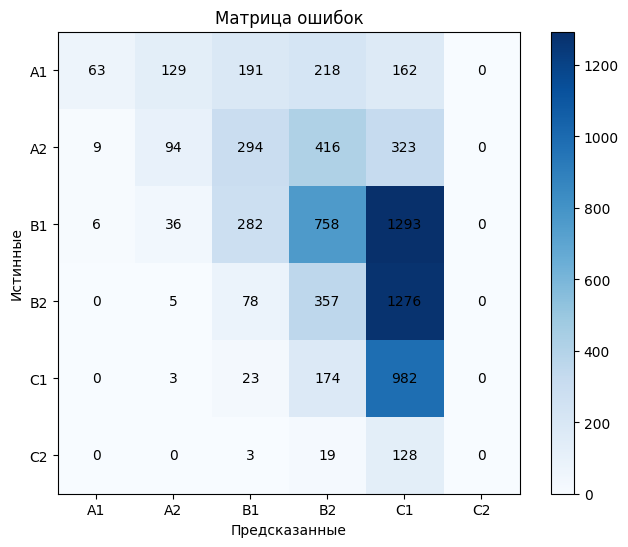

In [39]:
visualize_cm(true_labels, predictions)

# Предикт по среднему уровню

## Математическое округление

In [40]:
mean_levels = [round(sum(row) / len(row)) for row in levels]

true_labels, predictions = predict(df['textbook-assigned cefr level'], mean_levels)

Accuracy: 0.1449
F1 Micro: 0.1449
F1 Macro: 0.0979
F1 Weighted: 0.0751
MAE: 1.5512
              precision    recall  f1-score   support

           1       0.29      0.84      0.43       763
           2       0.08      0.33      0.13      1136
           3       0.14      0.02      0.03      2375
           4       0.00      0.00      0.00      1716
           5       0.00      0.00      0.00      1182
           6       0.00      0.00      0.00       150

    accuracy                           0.14      7322
   macro avg       0.08      0.20      0.10      7322
weighted avg       0.09      0.14      0.08      7322



0.1449
0.1449
0.0979
0.0751
1.5512


/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

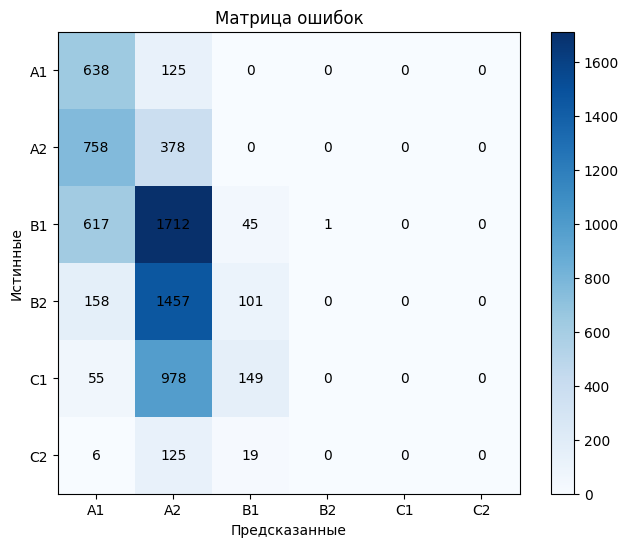

In [41]:
visualize_cm(true_labels, predictions)

## Округление вверх

In [42]:
mean_levels = [math.ceil(sum(row) / len(row)) for row in levels]

true_labels, predictions = predict(df['textbook-assigned cefr level'], mean_levels)

Accuracy: 0.2161
F1 Micro: 0.2161
F1 Macro: 0.1146
F1 Weighted: 0.1324
MAE: 1.2161
              precision    recall  f1-score   support

           1       0.81      0.08      0.15       763
           2       0.20      0.98      0.34      1136
           3       0.23      0.17      0.19      2375
           4       0.25      0.00      0.01      1716
           5       0.00      0.00      0.00      1182
           6       0.00      0.00      0.00       150

    accuracy                           0.22      7322
   macro avg       0.25      0.21      0.11      7322
weighted avg       0.25      0.22      0.13      7322



0.2161
0.2161
0.1146
0.1324
1.2161


/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

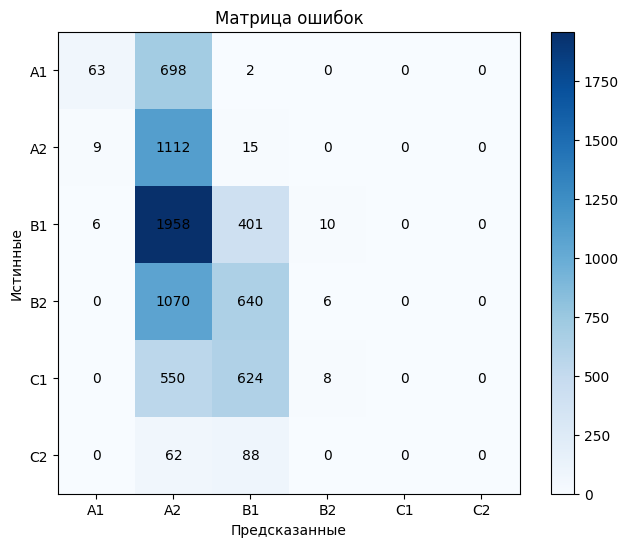

In [43]:
visualize_cm(true_labels, predictions)

## Округление вниз

In [44]:
mean_levels = [math.floor(sum(row) / len(row)) for row in levels]

true_labels, predictions = predict(df['textbook-assigned cefr level'], mean_levels)

Accuracy: 0.1078
F1 Micro: 0.1078
F1 Macro: 0.0457
F1 Weighted: 0.0311
MAE: 1.9702
              precision    recall  f1-score   support

           1       0.14      0.99      0.25       763
           2       0.01      0.02      0.01      1136
           3       0.29      0.00      0.01      2375
           4       0.00      0.00      0.00      1716
           5       0.00      0.00      0.00      1182
           6       0.00      0.00      0.00       150

    accuracy                           0.11      7322
   macro avg       0.07      0.17      0.05      7322
weighted avg       0.11      0.11      0.03      7322



0.1078
0.1078
0.0457
0.0311
1.9702


/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

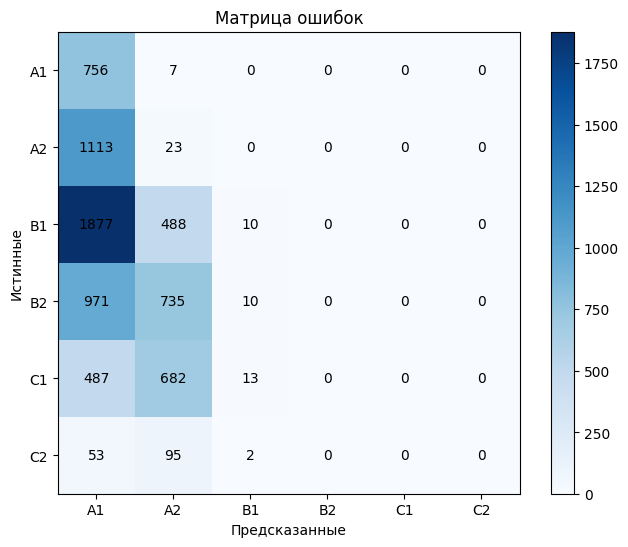

In [45]:
visualize_cm(true_labels, predictions)

# Предикт по самому частотному уровню

In [46]:
mode_levels = [math.ceil(sum(row) / len(row)) for row in levels]

true_labels, predictions = predict(df['textbook-assigned cefr level'], mode_levels)

Accuracy: 0.2161
F1 Micro: 0.2161
F1 Macro: 0.1146
F1 Weighted: 0.1324
MAE: 1.2161
              precision    recall  f1-score   support

           1       0.81      0.08      0.15       763
           2       0.20      0.98      0.34      1136
           3       0.23      0.17      0.19      2375
           4       0.25      0.00      0.01      1716
           5       0.00      0.00      0.00      1182
           6       0.00      0.00      0.00       150

    accuracy                           0.22      7322
   macro avg       0.25      0.21      0.11      7322
weighted avg       0.25      0.22      0.13      7322



0.2161
0.2161
0.1146
0.1324
1.2161


/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

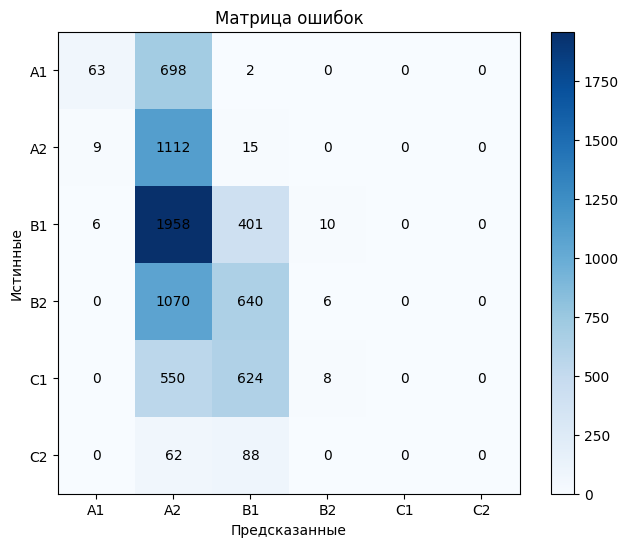

In [47]:
visualize_cm(true_labels, predictions)

# Предикт с помощью классификаторов по признакам количества слов каждого уровня

In [48]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)),
    ('CatBoost Classifier', CatBoostClassifier(random_state=42, verbose=False)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    # ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1, n_estimators=100))
]

In [49]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mae = mean_absolute_error(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mae': mae,
        'confusion_matrix': cm
    }

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['a1_count', 'a2_count', 'b1_count', 'b2_count', 'c1_count']], df['textbook-assigned cefr level'], test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [51]:
results = []

for model_name, model in models:
    print(f"Обработка: {model_name}")

    result = evaluate_model(model, model_name, X_train_scaled, X_test_scaled,
                               y_train, y_test)

    results.append(result)

Обработка: Logistic Regression
Обработка: Decision Tree
Обработка: Random Forest
Обработка: Gradient Boosting
Обработка: CatBoost Classifier
Обработка: SVM
Обработка: K-Nearest Neighbors
Обработка: Naive Bayes
Обработка: LightGBM


/home/tyumen/baseline_libs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [52]:
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'F1-Score micro': r['f1_micro'],
    'F1-Score macro': r['f1_macro'],
    'F1-Score weighted': r['f1_weighted'],
    'MAE': r['mae']
} for r in results])

results_df = results_df.sort_values(by='F1-Score weighted', ascending=False).reset_index()
results_df

,index,Model,Accuracy,F1-Score micro,F1-Score macro,F1-Score weighted,MAE
0,7,Naive Bayes,0.411604,0.411604,0.339544,0.398719,0.769966
1,8,LightGBM,0.404096,0.404096,0.335417,0.395272,0.791809
2,0,Logistic Regression,0.414334,0.414334,0.330497,0.393853,0.737201
3,5,SVM,0.419113,0.419113,0.326030,0.391906,0.737201
4,3,Gradient Boosting,0.398635,0.398635,0.336128,0.388952,0.774061
5,4,CatBoost Classifier,0.391809,0.391809,0.328493,0.385081,0.802730
6,2,Random Forest,0.372014,0.372014,0.314502,0.369033,0.874403
7,6,K-Nearest Neighbors,0.369283,0.369283,0.304364,0.358683,0.857338
8,1,Decision Tree,0.356314,0.356314,0.308778,0.352696,0.939249


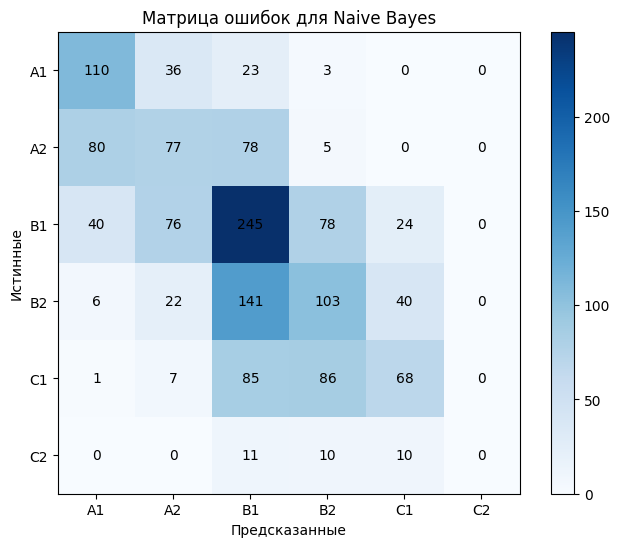

In [53]:
cm = [res['confusion_matrix'] for res in results if res['model_name'] == results_df['Model'][0]][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title(f'Матрица ошибок для {results_df['Model'][0]}')
plt.colorbar(im)
plt.show()